In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras import regularizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
# -----
# BƯỚC 1: TẢI DỮ LIỆU
# -----
print("--- Bước 1: Tải Dữ liệu ---")
try:
    df = pd.read_csv('weather_hanoi_cleaned.csv')
    df['time'] = pd.to_datetime(df['time'])
    df = df.set_index('time')
    print(f"Tải dữ liệu thành công. Tổng số {len(df)} hàng.")
except Exception as e:
    print(f"Lỗi khi đọc file: {e}")
    exit()

--- Bước 1: Tải Dữ liệu ---
Tải dữ liệu thành công. Tổng số 70752 hàng.


In [ ]:
# -----
# BƯỚC 2: PHÂN TÍCH VÀ PHÂN CHIA DỮ LIỆU
# -----
print("\n--- Bước 2: Phân tích và Phân chia Dữ liệu ---")

print("Phân tích mất cân bằng:")
print(df['will_rain_next_15min'].value_counts(normalize=True))

target_column = 'will_rain_next_15min'
feature_columns = [col for col in df.columns if col != target_column]
print(f"Số lượng đặc trưng (features): {len(feature_columns)}")
print(f"Các đặc trưng: {feature_columns}")

X = df[feature_columns]
y = df[target_column]

val_test_size = 0.30
test_size_relative = 0.5

X_train, X_val_test, y_train, y_val_test = train_test_split(
    X, y, test_size=val_test_size, shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_val_test, y_val_test, test_size=test_size_relative, shuffle=False
)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Validation: {X_val.shape}")
print(f"Kích thước tập Test: {X_test.shape}")


--- Bước 2: Phân tích và Phân chia Dữ liệu ---
Phân tích mất cân bằng:
will_rain_next_15min
0    0.786522
1    0.213478
Name: proportion, dtype: float64
Số lượng đặc trưng (features): 8
Các đặc trưng: ['temperature_2m_c', 'relative_humidity_2m', 'wind_speed_10m_km/h', 'surface_pressure_hpa', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
Kích thước tập Train: (49526, 8)
Kích thước tập Validation: (10613, 8)
Kích thước tập Test: (10613, 8)


In [ ]:
# -----
# BƯỚC 3: CHỈ CHUẨN HÓA 4/8 CỘT
# -----
print("\n--- Bước 3: Chỉ chuẩn hóa 4/8 cột ---")

cols_to_scale = ['temperature_2m_c', 'relative_humidity_2m', 'wind_speed_10m_km/h', 'surface_pressure_hpa']
cols_no_scale = ['hour_sin', 'hour_cos', 'month_sin', 'month_cos']

scaler = StandardScaler()
scaler.fit(X_train[cols_to_scale])

X_train_scaled_part = scaler.transform(X_train[cols_to_scale])
X_val_scaled_part = scaler.transform(X_val[cols_to_scale])
X_test_scaled_part = scaler.transform(X_test[cols_to_scale])

X_train_unscaled_part = X_train[cols_no_scale].values
X_val_unscaled_part = X_val[cols_no_scale].values
X_test_unscaled_part = X_test[cols_no_scale].values

X_train_processed = np.concatenate([X_train_scaled_part, X_train_unscaled_part], axis=1)
X_val_processed = np.concatenate([X_val_scaled_part, X_val_unscaled_part], axis=1)
X_test_processed = np.concatenate([X_test_scaled_part, X_test_unscaled_part], axis=1)

joblib.dump(scaler, 'weather_scaler_4_cols.pkl')
print("Đã lưu scaler (chỉ cho 4 cột) vào file 'weather_scaler_4_cols.pkl'")
print("Giá trị Mean (chỉ cho 4 cột, dùng cho ESP32):", scaler.mean_)
print("Giá trị Scale (1/std_dev) (chỉ cho 4 cột, dùng cho ESP32):", scaler.scale_)


--- Bước 3: Chỉ chuẩn hóa 4/8 cột ---
Đã lưu scaler (chỉ cho 4 cột) vào file 'weather_scaler_4_cols.pkl'
Giá trị Mean (chỉ cho 4 cột, dùng cho ESP32): [  23.68064249   78.8128054     7.24642006 1010.79923273]
Giá trị Scale (1/std_dev) (chỉ cho 4 cột, dùng cho ESP32): [ 5.72977378 13.98629596  3.8975096   7.45794426]


In [ ]:
# -----
# BƯỚC 4: TÁI CẤU TRÚC DỮ LIỆU 3D (SEQUENCES)
# -----
print("\n--- Bước 4: Tái cấu trúc Dữ liệu 3D ---")

N_PAST = 4
N_FEATURES = len(feature_columns)

def create_sequences(X, y, n_past):
    X_seq, y_seq = [], []
    for i in range(n_past, len(X)):
        X_seq.append(X[i - n_past:i, :])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_processed, y_train.values, N_PAST)
X_val_seq, y_val_seq = create_sequences(X_val_processed, y_val.values, N_PAST)
X_test_seq, y_test_seq = create_sequences(X_test_processed, y_test.values, N_PAST)

print(f"Hình dạng X_train mới (Samples, Timesteps, Features): {X_train_seq.shape}")
print(f"Hình dạng y_train mới (Samples,): {y_train_seq.shape}")
print(f"Hình dạng X_val mới: {X_val_seq.shape}")
print(f"Hình dạng X_test mới: {X_test_seq.shape}")


--- Bước 4: Tái cấu trúc Dữ liệu 3D ---
Hình dạng X_train mới (Samples, Timesteps, Features): (49522, 4, 8)
Hình dạng y_train mới (Samples,): (49522,)
Hình dạng X_val mới: (10609, 4, 8)
Hình dạng X_test mới: (10609, 4, 8)


In [ ]:
# -----
# BƯỚC 5: ĐIỀU CHỈNH CLASS WEIGHT
# -----
print("\n--- Bước 5: Điều chỉnh Class Weight thủ công ---")

class_weights = {0: 1.0, 1: 3.0}
print(f"Sử dụng class weights thủ công (tỉ lệ 1:3): {class_weights}")


--- Bước 5: Điều chỉnh Class Weight thủ công ---
Sử dụng class weights thủ công (tỉ lệ 1:3): {0: 1.0, 1: 3.0}


In [ ]:
# -----
# BƯỚC 6: XÂY DỰNG MODEL VỚI L2 REGULARIZATION
# -----
print("\n--- Bước 6: Xây dựng Model với L2 Regularization ---")

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
l2_strength = 0.0005

input_layer = Input(shape=(N_PAST, N_FEATURES))

x = LSTM(16,
         return_sequences=False,
         name="lstm_layer",
         unroll=True,
         kernel_regularizer=regularizers.l2(l2_strength)
         )(input_layer)

x = Dense(8,
          activation='relu',
          name="dense_layer",
          kernel_regularizer=regularizers.l2(l2_strength)
          )(x)
x = Dropout(0.2, name="dropout_layer")(x)

output_layer = Dense(1, activation='sigmoid', name="output_layer")(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.summary()


--- Bước 6: Xây dựng Model với L2 Regularization ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 16)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_layer (Dropout)         │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,745 (6.82 KB)

 Trainable params: 1,745 (6.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# -----
# BƯỚC 7: BIÊN DỊCH VÀ HUẤN LUYỆN
# -----
print("\n--- Bước 7: Biên dịch và Huấn luyện ---")

metrics = [
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    'accuracy'
]

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=metrics
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=100,
    batch_size=64,
    validation_data=(X_val_seq, y_val_seq),
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Hoàn tất huấn luyện.")


--- Bước 7: Biên dịch và Huấn luyện ---
Epoch 1/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.7503 - loss: 0.7080 - precision: 0.3897 - recall: 0.7497 - val_accuracy: 0.7508 - val_loss: 0.4848 - val_precision: 0.4831 - val_recall: 0.7336 - learning_rate: 0.0010
Epoch 2/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8393 - loss: 0.5502 - precision: 0.5196 - recall: 0.7999 - val_accuracy: 0.7541 - val_loss: 0.4728 - val_precision: 0.4874 - val_recall: 0.7245 - learning_rate: 0.0010
Epoch 3/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8497 - loss: 0.5216 - precision: 0.5360 - recall: 0.8117 - val_accuracy: 0.7536 - val_loss: 0.4871 - val_precision: 0.4871 - val_recall: 0.7416 - learning_rate: 0.0010
Epoch 4/100
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8479 - loss: 0.5125 - precision: 0.5329 - recall: 0.8080 - val_accuracy: 0.7355 - val_loss: 0.5192 - val_precision: 0.4651 - val_recall: 0.7718 - learning_rate: 0.0010
Epoch 5/100
774/77


--- Bước 7b: Vẽ đồ thị quá trình huấn luyện ---
Đã lưu đồ thị vào file 'training_history_v2.png'


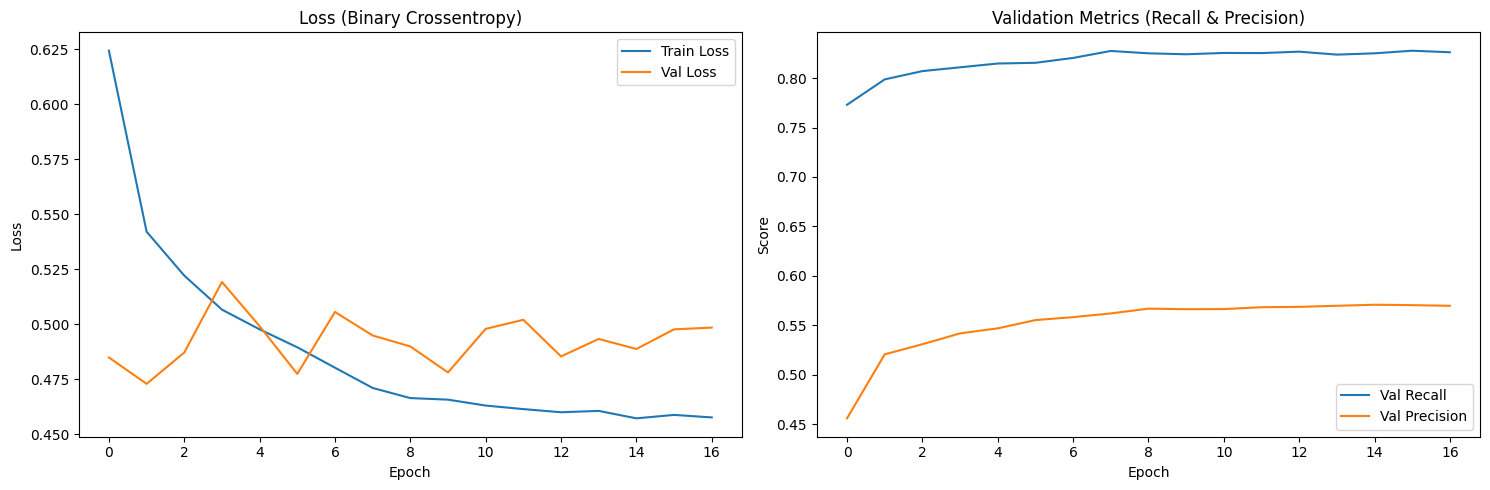

In [ ]:
# -----
# BƯỚC 7b: VẼ ĐỒ THỊ HUẤN LUYỆN
# -----
print("\n--- Bước 7b: Vẽ đồ thị quá trình huấn luyện ---")
try:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss (Binary Crossentropy)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['recall'], label='Val Recall')
    ax2.plot(history.history['precision'], label='Val Precision')
    ax2.set_title('Validation Metrics (Recall & Precision)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Score')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('training_history_v2.png')
    print("Đã lưu đồ thị vào file 'training_history_v2.png'")
except Exception as e:
    print(f"Lỗi khi vẽ đồ thị: {e}")

In [ ]:
# -----
# BƯỚC 8: ĐÁNH GIÁ TRÊN TẬP VALIDATION VỚI NGƯỠNG 0.6
# -----
print("\n--- Bước 8: Đánh giá trên tập Validation với ngưỡng 0.6 ---")

THRESHOLD = 0.6
y_val_probs = model.predict(X_val_seq)
y_val_pred = (y_val_probs > THRESHOLD).astype(int)

print(classification_report(y_val_seq, y_val_pred,
                            target_names=['0 (Không mưa)', '1 (Có mưa)'],
                            zero_division=0))

cm_val = confusion_matrix(y_val_seq, y_val_pred)
print("Ma trận nhầm lẫn (Validation):")
print(cm_val)

report_val = classification_report(y_val_seq, y_val_pred,
                                   output_dict=True,
                                   zero_division=0)
precision_1_val = report_val['1']['precision']
recall_1_val = report_val['1']['recall']
f1_score_1_val = report_val['1']['f1-score']

print(f"Báo động giả (FP): {cm_val[0][1]}")
print(f"Bỏ lỡ mưa (FN): {cm_val[1][0]}")
print(f"Precision (class 1): {precision_1_val:.4f}")
print(f"Recall (class 1): {recall_1_val:.4f}")
print(f"F1-Score (class 1): {f1_score_1_val:.4f}")


--- Bước 8: Đánh giá trên tập Validation với ngưỡng 0.6 ---
332/332 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
               precision    recall  f1-score   support

0 (Không mưa)       0.89      0.83      0.86      8094
   1 (Có mưa)       0.54      0.66      0.60      2515

     accuracy                           0.79     10609
    macro avg       0.72      0.74      0.73     10609
 weighted avg       0.81      0.79      0.80     10609

Ma trận nhầm lẫn (Validation):
[[6706 1388]
 [ 856 1659]]
Báo động giả (FP): 1388
Bỏ lỡ mưa (FN): 856
Precision (class 1): 0.5445
Recall (class 1): 0.6596
F1-Score (class 1): 0.5965



--- Bước 9: Đánh giá cuối cùng trên tập Test với ngưỡng 0.6 ---
332/332 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ROC-AUC Score (Test): 0.7737


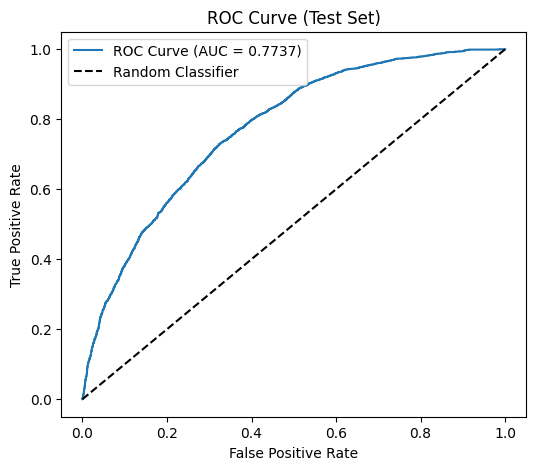

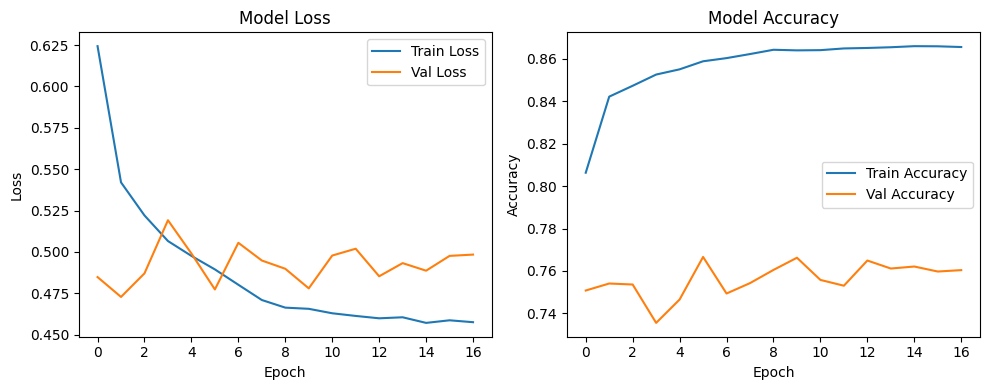


--- BÁO CÁO PHÂN LOẠI CUỐI CÙNG (TRÊN TẬP TEST) ---
               precision    recall  f1-score   support

0 (Không mưa)       0.88      0.44      0.59      6364
   1 (Có mưa)       0.52      0.91      0.66      4245

     accuracy                           0.63     10609
    macro avg       0.70      0.68      0.63     10609
 weighted avg       0.74      0.63      0.62     10609


--- MA TRẬN NHẦM LẪN CUỐI CÙNG (TRÊN TẬP TEST) ---
[[2802 3562]
 [ 371 3874]]
True Negatives (TN): 2802
False Positives (FP): 3562 (Báo động giả)
False Negatives (FN): 371 (Bỏ lỡ mưa)
True Positives (TP): 3874

--- Đang chuyển đổi sang TFLite ---
Saved artifact at '/tmp/tmpttaftdfx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140187110661904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140187110664784: 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# -----
# BƯỚC 9: ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST VÀ LƯU MODEL
# -----
print(f"\n--- Bước 9: Đánh giá cuối cùng trên tập Test với ngưỡng {THRESHOLD} ---")

y_test_probs = model.predict(X_test_seq)
y_test_pred = (y_test_probs > THRESHOLD).astype(int)

# Tính ROC-AUC
auc_score = roc_auc_score(y_test_seq, y_test_probs)
print(f"ROC-AUC Score (Test): {auc_score:.4f}")

# Vẽ ROC Curve
fpr, tpr, _ = roc_curve(y_test_seq, y_test_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.savefig('roc_curve.png')
plt.show()

# Learning Curves (đã có history, thêm plot nếu cần)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()

print("\n--- BÁO CÁO PHÂN LOẠI CUỐI CÙNG (TRÊN TẬP TEST) ---")
print(classification_report(y_test_seq, y_test_pred, target_names=['0 (Không mưa)', '1 (Có mưa)']))

print("\n--- MA TRẬN NHẦM LẪN CUỐI CÙNG (TRÊN TẬP TEST) ---")
cm_test = confusion_matrix(y_test_seq, y_test_pred)
print(cm_test)
print(f"True Negatives (TN): {cm_test[0][0]}")
print(f"False Positives (FP): {cm_test[0][1]} (Báo động giả)")
print(f"False Negatives (FN): {cm_test[1][0]} (Bỏ lỡ mưa)")
print(f"True Positives (TP): {cm_test[1][1]}")

# Chuyển đổi và lưu TFLite
print("\n--- Đang chuyển đổi sang TFLite ---")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('lstm_model_v2_final.tflite', 'wb') as f:
    f.write(tflite_model)

print("\nĐÃ LƯU MODEL VÀO FILE 'lstm_model_v2_final.tflite'")

print("\n--- Kiểm tra Op Codes trong file TFLite ---")
try:
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    ops = set()
    for detail in interpreter._get_ops_details():
        ops.add(detail['op_name'])
    print(f"Các Op Codes sử dụng: {ops} (An toàn cho ESP32)")
except Exception as e:
    print(f"Lỗi khi tải TFLite interpreter: {e}")

print("\n--- HOÀN TẤT ---")
print(f"Việc của bạn trên ESP32 là: dùng model này và chỉ báo mưa khi `probability > {THRESHOLD}`.")